In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import networkx as nx

In [2]:
df = pd.read_parquet("../outputs/clean_all.parquet")
df.shape

(142502, 29)

In [41]:
OUT_DIR    = "../outputs"
GRAPH_PATH = "../outputs/graphs.pkl"
with open(GRAPH_PATH, 'rb') as f:
    graphs = pickle.load(f)


In [4]:
edge_weights = (
    df.groupby(['source_center', 'destination_center'])
    .agg(
        weight      = ('segment_factor', 'median'),
        trip_count  = ('segment_factor', 'count'),
        mean_factor = ('segment_factor', 'mean'),
        std_factor  = ('segment_factor', 'std'),
        source_name = ('source_name',   'first'),
        dest_name   = ('destination_name', 'first'),
    )
    .reset_index()
)

In [5]:
name_lookup = {}
for _, row in edge_weights.iterrows():
    name_lookup[row['source_center']] = row['source_name']
    name_lookup[row['destination_center']] = row['dest_name']

## Compute graph metrics

We compute four metrics for every hub:

**Betweenness Centrality** — how often a hub lies on the shortest path between
other hubs. A hub with high betweenness is a structural chokepoint — if it slows
down, it cascades delays across the entire network. We use `weight` as the cost
parameter so high-delay corridors are penalised in path computation.

**In-degree / Out-degree** — how many corridors arrive at / depart from a hub.
High in-degree = major receiving hub. High out-degree = major dispatch hub.

**Clustering Coefficient** — the fraction of a hub's neighbours that are also
connected to each other. A high clustering hub is embedded in a dense regional
sub-network — delays there ripple through the whole regional cluster, not just
direct corridors. Computed using `nx.clustering()` on the directed graph with
edge weights.

**Weighted degree** — sum of edge weights on all connected corridors. A hub
with high weighted degree is both busy AND delayed — the worst combination.


In [6]:
G = graphs['main']
betweenness = nx.betweenness_centrality(G, weight='weight', normalized=True)

In [7]:
clustering  = nx.clustering(G, weight='weight')

In [8]:
# Degree metrics
in_degree  = dict(G.in_degree())
out_degree = dict(G.out_degree())
degree     = dict(G.degree())

# Weighted degree — sum of edge weights
in_weight  = {n: sum(G[u][n]['weight'] for u in G.predecessors(n)) for n in G.nodes()}
out_weight = {n: sum(G[n][v]['weight'] for v in G.successors(n))   for n in G.nodes()}

In [9]:
print(f"\n  Betweenness  — max: {max(betweenness.values()):.4f}   mean: {np.mean(list(betweenness.values())):.4f}")
print(f"  In-degree    — max: {max(in_degree.values())}    mean: {np.mean(list(in_degree.values())):.2f}")
print(f"  Out-degree   — max: {max(out_degree.values())}   mean: {np.mean(list(out_degree.values())):.2f}")
print(f"  Clustering   — max: {max(clustering.values()):.4f}   mean: {np.mean(list(clustering.values())):.4f}")
print(f"  Non-zero clustering hubs: {sum(1 for v in clustering.values() if v > 0):,}")


  Betweenness  — max: 0.2332   mean: 0.0015
  In-degree    — max: 45    mean: 1.68
  Out-degree   — max: 49   mean: 1.68
  Clustering   — max: 0.4604   mean: 0.0345
  Non-zero clustering hubs: 817


In [39]:
# Check graph connectivity
components = list(nx.weakly_connected_components(G))
largest    = max(len(c) for c in components)
print(f"Weakly connected components : {len(components)}")
print(f"Largest component size      : {largest:,} nodes  ({largest/G.number_of_nodes()*100:.1f}% of network)")
print(f"Small isolated components   : {sum(1 for c in components if len(c) < 5)}")
print(f"\nNote: hubs in isolated components have betweenness = 0")
print(f"and won't appear as structural bottlenecks regardless of delay.")

Weakly connected components : 64
Largest component size      : 1,353 nodes  (81.7% of network)
Small isolated components   : 44

Note: hubs in isolated components have betweenness = 0
and won't appear as structural bottlenecks regardless of delay.


In [10]:
# Assemble into hub metrics dataframe
hub_metrics = pd.DataFrame({
    'hub_code'     : list(G.nodes()),
    'hub_name'     : [name_lookup.get(n, n) for n in G.nodes()],
    'betweenness'  : [betweenness[n]  for n in G.nodes()],
    'clustering'   : [clustering[n]   for n in G.nodes()],
    'in_degree'    : [in_degree[n]    for n in G.nodes()],
    'out_degree'   : [out_degree[n]   for n in G.nodes()],
    'total_degree' : [degree[n]       for n in G.nodes()],
    'in_weight'    : [in_weight[n]    for n in G.nodes()],
    'out_weight'   : [out_weight[n]   for n in G.nodes()],
})

hub_metrics['avg_edge_weight'] = (
    (hub_metrics['in_weight'] + hub_metrics['out_weight']) /
     hub_metrics['total_degree'].replace(0, np.nan)
)

In [11]:
hub_metrics.shape

(1657, 10)

In [12]:
print(hub_metrics.sort_values('betweenness', ascending=False).head(10)[
    ['hub_name','betweenness','clustering','in_degree','out_degree','avg_edge_weight']
].round(4).to_string(index=False))

                         hub_name  betweenness  clustering  in_degree  out_degree  avg_edge_weight
    Gurgaon_Bilaspur_HB (Haryana)       0.2332      0.0036         45          49           1.5698
 Bangalore_Nelmngla_H (Karnataka)       0.1526      0.0072         36          35           1.5471
 Kolkata_Dankuni_HB (West Bengal)       0.0806      0.0055         24          22           2.9575
 Hyderabad_Shamshbd_H (Telangana)       0.0769      0.0052         30          27           1.8109
Bhiwandi_Mankoli_HB (Maharashtra)       0.0532      0.0095         29          29           2.0091
   Chandigarh_Mehmdpur_H (Punjab)       0.0530      0.0042         32          29           1.7274
          Delhi_Airport_H (Delhi)       0.0473      0.0067         21          24           2.0962
       Sonipat_Kundli_H (Haryana)       0.0472      0.0051         20          20           1.9483
    Pune_Tathawde_H (Maharashtra)       0.0454      0.0075         23          20           1.7630
          

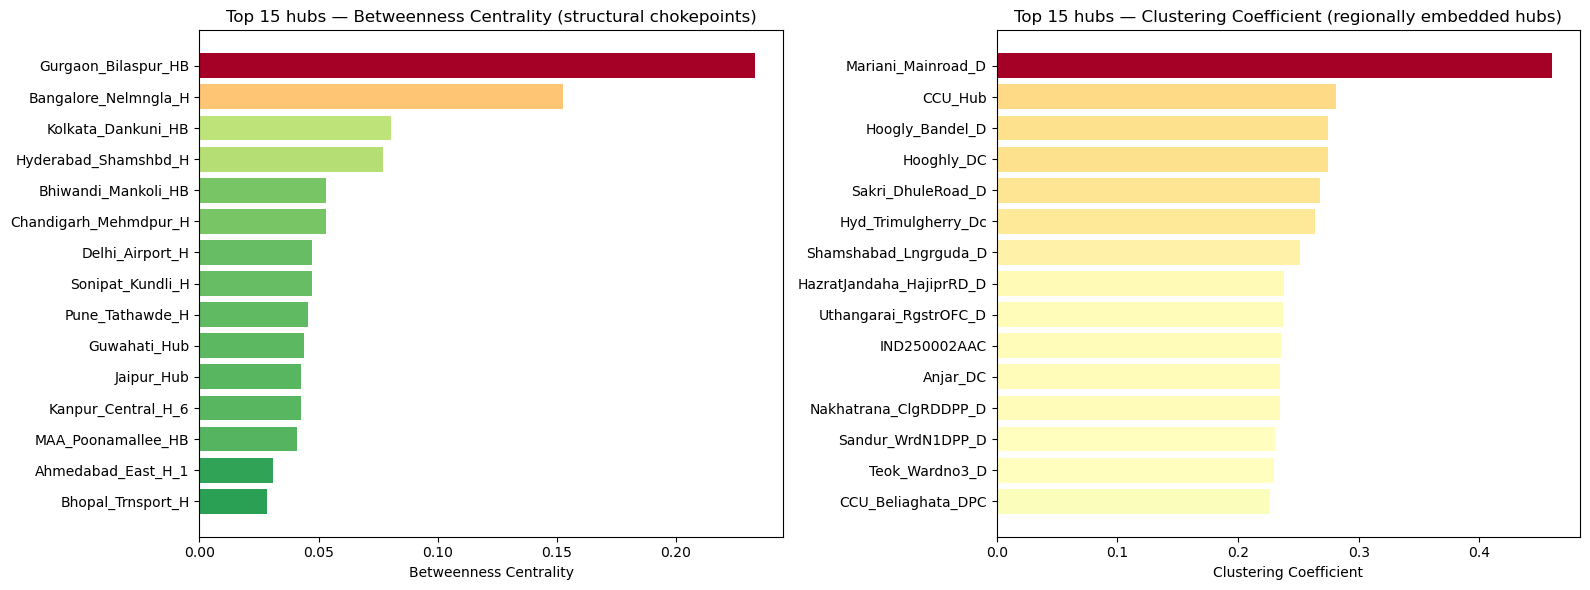

In [13]:
# Side-by-side bar charts — betweenness vs clustering top 15
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Betweenness
top15_bc = hub_metrics.nlargest(15, 'betweenness')
axes[0].barh(
    top15_bc['hub_name'].str.split('(').str[0].str.strip(),
    top15_bc['betweenness'],
    color=plt.cm.RdYlGn_r(top15_bc['betweenness'] / top15_bc['betweenness'].max())
)
axes[0].set_xlabel("Betweenness Centrality")
axes[0].set_title("Top 15 hubs — Betweenness Centrality (structural chokepoints)")
axes[0].invert_yaxis()

# Clustering
top15_cl = hub_metrics[hub_metrics['clustering'] > 0].nlargest(15, 'clustering')
axes[1].barh(
    top15_cl['hub_name'].str.split('(').str[0].str.strip(),
    top15_cl['clustering'],
    color=plt.cm.RdYlGn_r(top15_cl['clustering'] / top15_cl['clustering'].max())
)
axes[1].set_xlabel("Clustering Coefficient")
axes[1].set_title("Top 15 hubs — Clustering Coefficient (regionally embedded hubs)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## Hub-level SLA breach profile

SLA data tells us actual damage caused.

We use `is_cutoff = True` rows only — deliveries that had a promised deadline.

**SLA breach definition:** `segment_factor > 1.2` — actual time exceeded
OSRM prediction by more than 20%

**Primary ranking metric: `total_cutoff_score`** — the sum of `cutoff_factor`
across all breached trips originating from a hub. This directly measures
SLA breach *contribution* — a hub contributing 1,000 cutoff points is more
damaging than one contributing 100, regardless of breach rate.


In [14]:
sla_df = df[df['is_cutoff'] == True].copy()
sla_df['is_breach'] = sla_df['segment_factor'] > 1.2

In [15]:
print(f"SLA-bound rows  : {len(sla_df):,}")
print(f"Breach rows     : {sla_df['is_breach'].sum():,}  ({sla_df['is_breach'].mean()*100:.1f}%)")
print(f"cutoff_factor range: {sla_df['cutoff_factor'].min()} – {sla_df['cutoff_factor'].max()}")

SLA-bound rows  : 118,708
Breach rows     : 99,512  (83.8%)
cutoff_factor range: 9 – 1914


In [16]:
# SLA profile per source hub
sla_profile = (
    sla_df.groupby('source_center')
    .agg(
        hub_name           = ('source_name','first'),
        total_trips        = ('is_breach','count'),
        total_breaches     = ('is_breach','sum'),
        breach_rate        = ('is_breach','mean'),
        mean_cutoff_factor = ('cutoff_factor','mean'),
        total_cutoff_score = ('cutoff_factor','sum'),   # PRIMARY SLA metric
        mean_seg_factor    = ('segment_factor','mean'),
    )
    .reset_index()
)

In [17]:
print(f"\nTop 10 by total_cutoff_score (SLA breach contribution):\n")
print(sla_profile.nlargest(10, 'total_cutoff_score')[
    ['hub_name','total_trips','total_breaches','breach_rate',
     'mean_cutoff_factor','total_cutoff_score']
].to_string(index=False))


Top 10 by total_cutoff_score (SLA breach contribution):

                         hub_name  total_trips  total_breaches  breach_rate  mean_cutoff_factor  total_cutoff_score
    Gurgaon_Bilaspur_HB (Haryana)        22275           18056     0.810595          540.512952            12039926
 Bangalore_Nelmngla_H (Karnataka)         9204            7539     0.819100          551.478053             5075804
Bhiwandi_Mankoli_HB (Maharashtra)         8264            7445     0.900895          407.310624             3366015
    Pune_Tathawde_H (Maharashtra)         3665            3003     0.819372          286.130969             1048670
 Kolkata_Dankuni_HB (West Bengal)         2350            1995     0.848936          395.072766              928421
             Guwahati_Hub (Assam)         1478            1327     0.897835          595.953315              880819
              Surat_HUB (Gujarat)         2097            1808     0.862184          419.823557              880370
 Hyderabad_Sha

We now join `hub_metrics` (graph structure) with `sla_profile` (SLA damage)
into a single `combined` dataframe — one row per hub, all metrics together.

In [18]:
# Merge on hub code
combined = hub_metrics.merge(
    sla_profile[[
        'source_center', 'total_trips', 'total_breaches',
        'breach_rate', 'mean_cutoff_factor',
        'total_cutoff_score', 'mean_seg_factor'
    ]],
    left_on='hub_code', right_on='source_center', how='left'
).drop(columns='source_center')

# Fill hubs with no SLA trips with 0
fill_cols = ['total_trips','total_breaches','breach_rate',
             'mean_cutoff_factor','total_cutoff_score','mean_seg_factor']
combined[fill_cols] = combined[fill_cols].fillna(0)

print(f"combined shape : {combined.shape}")
print(f"columns : {combined.columns.tolist()}")

combined shape : (1657, 16)
columns : ['hub_code', 'hub_name', 'betweenness', 'clustering', 'in_degree', 'out_degree', 'total_degree', 'in_weight', 'out_weight', 'avg_edge_weight', 'total_trips', 'total_breaches', 'breach_rate', 'mean_cutoff_factor', 'total_cutoff_score', 'mean_seg_factor']


## Derive data-driven weights using correlation

**Method:** Compute the absolute correlation of each graph metric
(`betweenness`, `breach_rate`, `clustering`) with `total_cutoff_score`
(SLA breach contribution). Normalise correlations to sum to 1 → these
become the weights.

**Rationale:** A metric that strongly predicts SLA damage deserves more
weight. This makes the scoring model data-driven and fully defensible



In [19]:
# Normalise metrics to 0-1
def norm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx > mn else s * 0

combined['norm_cutoff_score'] = norm(combined['total_cutoff_score'])
combined['norm_betweenness']  = norm(combined['betweenness'])
combined['norm_breach_rate']  = norm(combined['breach_rate'])
combined['norm_clustering']   = norm(combined['clustering'])

# Correlation of each metric with total_cutoff_score
predictor_cols = ['norm_betweenness', 'norm_breach_rate', 'norm_clustering']
corr_with_sla  = (
    combined[predictor_cols + ['norm_cutoff_score']]
    .corr()['norm_cutoff_score']
    .drop('norm_cutoff_score')
)

# Normalise absolute correlations → weights
weights = corr_with_sla.abs() / corr_with_sla.abs().sum()

print("Correlation with total_cutoff_score:")
for m, c in corr_with_sla.items():
    print(f"  {m:<22} : {c:.4f}")

print(f"\nData-driven weights:")
print(f"  norm_betweenness : {weights['norm_betweenness']:.4f}  ({weights['norm_betweenness']*100:.1f}%)")
print(f"  norm_breach_rate : {weights['norm_breach_rate']:.4f}  ({weights['norm_breach_rate']*100:.1f}%)")
print(f"  norm_clustering  : {weights['norm_clustering']:.4f}  ({weights['norm_clustering']*100:.1f}%)")
print(f"  sum              : {weights.sum():.4f}")


Correlation with total_cutoff_score:
  norm_betweenness       : 0.8709
  norm_breach_rate       : 0.0162
  norm_clustering        : -0.0286

Data-driven weights:
  norm_betweenness : 0.9511  (95.1%)
  norm_breach_rate : 0.0177  (1.8%)
  norm_clustering  : 0.0313  (3.1%)
  sum              : 1.0000


In [20]:
W_BETWEENNESS = weights['norm_betweenness']
W_BREACH_RATE = weights['norm_breach_rate']
W_CLUSTERING  = weights['norm_clustering']

combined['bottleneck_score'] = (
    W_BETWEENNESS * combined['norm_betweenness'] +
    W_BREACH_RATE * combined['norm_breach_rate'] +
    W_CLUSTERING  * combined['norm_clustering']
)

**Why `total_cutoff_score` is not in the score itself:**
It was used to derive the weights. Including it would be circular — the
score would just rediscover total_cutoff_score. Instead the score ranks
hubs by structural + operational profile, calibrated against SLA damage.

In [21]:
print("Top 15 bottleneck hubs (data-driven weights):\n")
print(combined.nlargest(15, 'bottleneck_score')[
    ['hub_name','total_cutoff_score','betweenness','clustering',
     'breach_rate','total_breaches','bottleneck_score']
].round(4).to_string(index=False))

Top 15 bottleneck hubs (data-driven weights):

                          hub_name  total_cutoff_score  betweenness  clustering  breach_rate  total_breaches  bottleneck_score
     Gurgaon_Bilaspur_HB (Haryana)          12039926.0       0.2332      0.0036       0.8106         18056.0            0.9656
  Bangalore_Nelmngla_H (Karnataka)           5075804.0       0.1526      0.0072       0.8191          7539.0            0.6373
  Kolkata_Dankuni_HB (West Bengal)            928421.0       0.0806      0.0055       0.8489          1995.0            0.3438
  Hyderabad_Shamshbd_H (Telangana)            709235.0       0.0769      0.0052       0.8860          2667.0            0.3294
 Bhiwandi_Mankoli_HB (Maharashtra)           3366015.0       0.0532      0.0095       0.9009          7445.0            0.2333
    Chandigarh_Mehmdpur_H (Punjab)            289301.0       0.0530      0.0042       0.8461          1759.0            0.2315
           Delhi_Airport_H (Delhi)            602972.0       0.0

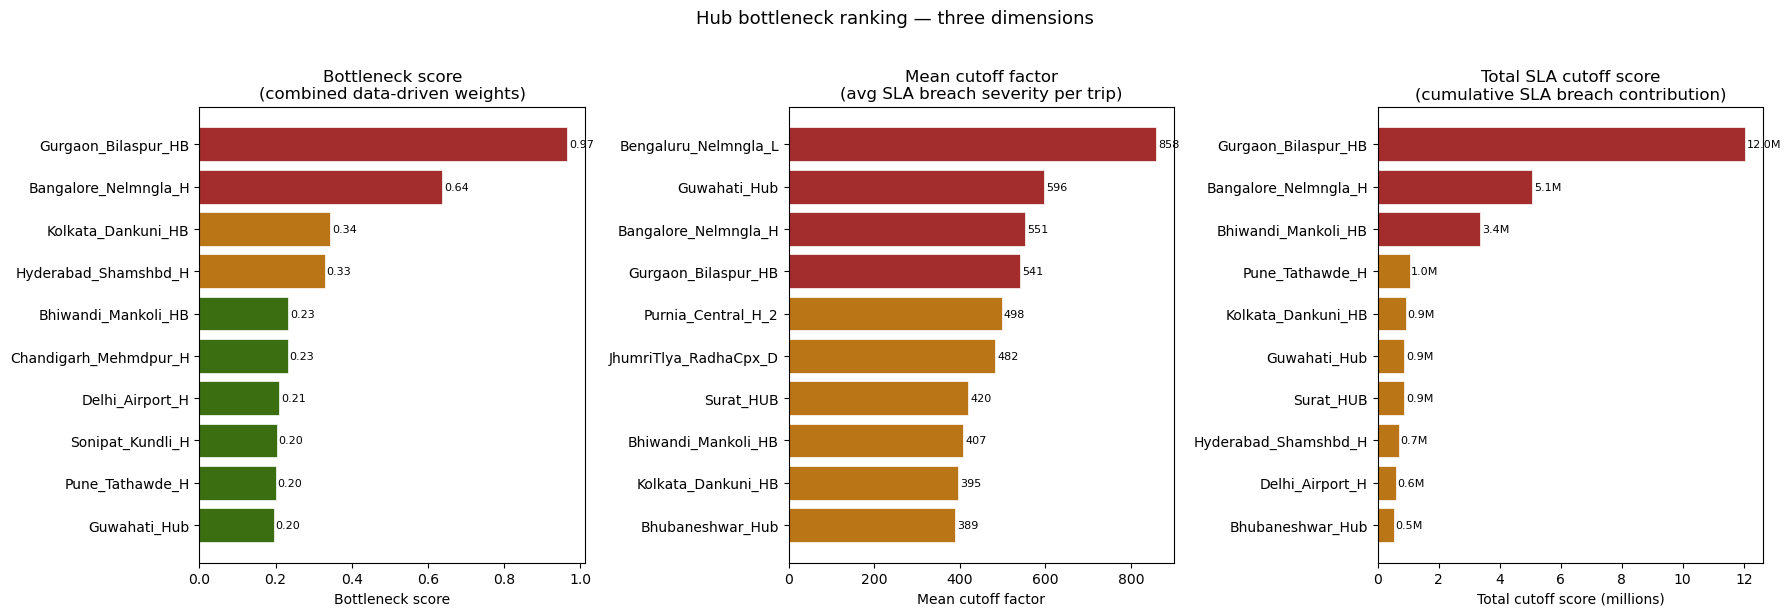


Key insight: hubs appearing in multiple charts are the true bottlenecks.
Gurgaon and Bangalore dominate all three — clear upgrade priority.


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

top10 = combined.nlargest(10, 'bottleneck_score').copy()
top10['short_name'] = top10['hub_name'].str.split('(').str[0].str.strip()

# ── Chart 1: Bottleneck score ──────────────────────────────────────────
colors_score = ['#A32D2D' if s > 0.6 else '#BA7517' if s > 0.3 else '#3B6D11'
                for s in top10['bottleneck_score']]
axes[0].barh(top10['short_name'], top10['bottleneck_score'],
             color=colors_score, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel("Bottleneck score")
axes[0].set_title("Bottleneck score\n(combined data-driven weights)")
axes[0].invert_yaxis()
for i, v in enumerate(top10['bottleneck_score']):
    axes[0].text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=8)

# ── Chart 2: Mean cutoff factor (severity) ────────────────────────────
top10_cf = combined[combined['total_trips'] >= 50].nlargest(10, 'mean_cutoff_factor').copy()
top10_cf['short_name'] = top10_cf['hub_name'].str.split('(').str[0].str.strip()

colors_cf = ['#A32D2D' if s > 500 else '#BA7517' if s > 200 else '#3B6D11'
             for s in top10_cf['mean_cutoff_factor']]

axes[1].barh(top10_cf['short_name'], top10_cf['mean_cutoff_factor'],
             color=colors_cf, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel("Mean cutoff factor")
axes[1].set_title("Mean cutoff factor\n(avg SLA breach severity per trip)")
axes[1].invert_yaxis()
for i, v in enumerate(top10_cf['mean_cutoff_factor']):
    axes[1].text(v + 5, i, f'{v:.0f}', va='center', fontsize=8)

# ── Chart 3: Total cutoff score ────────────────────────────────────────
top10_sla = combined.nlargest(10, 'total_cutoff_score').copy()
top10_sla['short_name'] = top10_sla['hub_name'].str.split('(').str[0].str.strip()
colors_sla = ['#A32D2D' if s > 3e6 else '#BA7517' if s > 5e5 else '#3B6D11'
              for s in top10_sla['total_cutoff_score']]
axes[2].barh(top10_sla['short_name'], top10_sla['total_cutoff_score'] / 1e6,
             color=colors_sla, edgecolor='white', linewidth=0.5)
axes[2].set_xlabel("Total cutoff score (millions)")
axes[2].set_title("Total SLA cutoff score\n(cumulative SLA breach contribution)")
axes[2].invert_yaxis()
for i, v in enumerate(top10_sla['total_cutoff_score']):
    axes[2].text(v/1e6 + 0.05, i, f'{v/1e6:.1f}M', va='center', fontsize=8)

plt.suptitle("Hub bottleneck ranking — three dimensions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nKey insight: hubs appearing in multiple charts are the true bottlenecks.")
print("Gurgaon and Bangalore dominate all three — clear upgrade priority.")

In [25]:
top5 = combined.nlargest(5, 'bottleneck_score').reset_index(drop=True)

print("=" * 70)
print("  TOP 5 BOTTLENECK HUBS — ranked by SLA breach contribution")
print("=" * 70)
for i, row in top5.iterrows():
    print(f"\n  #{i+1}  {row['hub_name']}")
    print(f"       Betweenness centrality  : {row['betweenness']:.4f}")
    print(f"       Clustering coefficient  : {row['clustering']:.4f}")
    print(f"       In-degree / Out-degree  : {int(row['in_degree'])} / {int(row['out_degree'])}")
    print(f"       SLA breach rate         : {row['breach_rate']*100:.1f}%")
    print(f"       Mean cutoff factor      : {row['mean_cutoff_factor']:.1f}")
    print(f"       Total SLA breaches      : {int(row['total_breaches']):,}")
    print(f"       Total cutoff score      : {row['total_cutoff_score']:,.0f}")
    print(f"       Bottleneck score        : {row['bottleneck_score']:.4f}")
print("\n" + "=" * 70)


  TOP 5 BOTTLENECK HUBS — ranked by SLA breach contribution

  #1  Gurgaon_Bilaspur_HB (Haryana)
       Betweenness centrality  : 0.2332
       Clustering coefficient  : 0.0036
       In-degree / Out-degree  : 45 / 49
       SLA breach rate         : 81.1%
       Mean cutoff factor      : 540.5
       Total SLA breaches      : 18,056
       Total cutoff score      : 12,039,926
       Bottleneck score        : 0.9656

  #2  Bangalore_Nelmngla_H (Karnataka)
       Betweenness centrality  : 0.1526
       Clustering coefficient  : 0.0072
       In-degree / Out-degree  : 36 / 35
       SLA breach rate         : 81.9%
       Mean cutoff factor      : 551.5
       Total SLA breaches      : 7,539
       Total cutoff score      : 5,075,804
       Bottleneck score        : 0.6373

  #3  Kolkata_Dankuni_HB (West Bengal)
       Betweenness centrality  : 0.0806
       Clustering coefficient  : 0.0055
       In-degree / Out-degree  : 24 / 22
       SLA breach rate         : 84.9%
       Mean cutoff 

**Chronic delay definition:**
- `median segment_factor > 1.2×` — consistently 20% over OSRM
- `trip_count >= 5` — statistically reliable sample
- Low coefficient of variation (CV = std/mean) — consistent, not random spikes


In [26]:
corridor_audit = edge_weights.copy()

corridor_audit['is_chronic'] = (
    (corridor_audit['weight'] > 1.2) &
    (corridor_audit['trip_count'] >= 5)
)
corridor_audit['cv'] = (
    corridor_audit['std_factor'] / corridor_audit['mean_factor'].replace(0, np.nan)
).fillna(0)


> **Key finding:** 73.7% of all corridors are chronically delayed (actual time 
> exceeds OSRM by >20% consistently). This is not a corridor-level problem — 
> it is a systemic network-wide underestimation by OSRM.

In [27]:

print(f"Total corridors          : {len(corridor_audit):,}")
print(f"Chronic delay corridors  : {corridor_audit['is_chronic'].sum():,}  ({corridor_audit['is_chronic'].mean()*100:.1f}%)")
print(f"\nTop 15 chronic corridors (reliable + consistently high delay):\n")
chronic = corridor_audit[corridor_audit['is_chronic']].nlargest(15, 'weight')[
    ['source_name','dest_name','weight','trip_count','mean_factor','std_factor','cv']
].round(3)
chronic.columns = ['Source','Destination','Median Factor','Trips','Mean Factor','Std','CV']
print(chronic.to_string(index=False))


Total corridors          : 2,783
Chronic delay corridors  : 2,052  (73.7%)

Top 15 chronic corridors (reliable + consistently high delay):

                              Source                         Destination  Median Factor  Trips  Mean Factor   Std    CV
  Kanpur_Central_D_7 (Uttar Pradesh)  Kanpur_Central_H_6 (Uttar Pradesh)         11.600     33        7.540 4.868 0.646
   Shirpur_KrantiNgr_D (Maharashtra)      Dhule_MIDCAvdn_I (Maharashtra)         11.600     18        8.689 4.372 0.503
  Simlapal_Central_D_1 (West Bengal)      Hura_Central_D_1 (West Bengal)         11.600     10        8.524 4.857 0.570
   Helencha_ColnyDPP_D (West Bengal)    Kolkata_Dankuni_HB (West Bengal)         11.600      5       11.600 0.000 0.000
    HazratJandaha_HajiprRD_D (Bihar)         Muzaffrpur_Bbganj_I (Bihar)         11.357     16        9.854 2.823 0.286
         Surat_Central_D_9 (Gujarat)         Surat_Central_I_4 (Gujarat)         10.286     15        9.729 2.017 0.207
           Bhubanesh

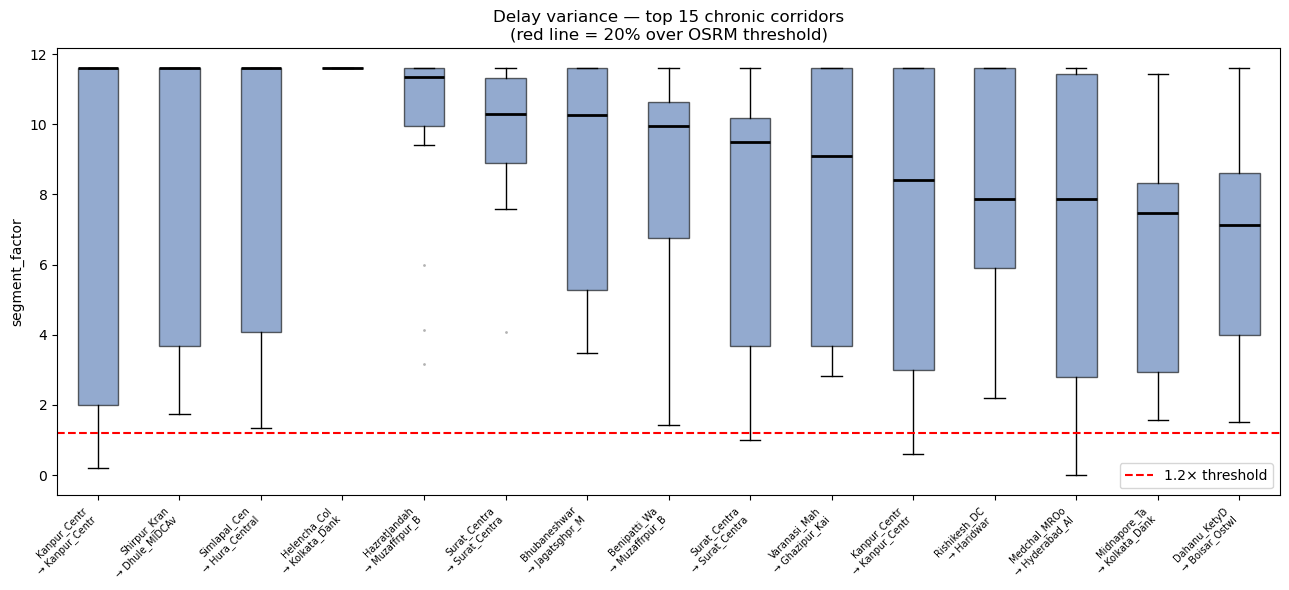

In [28]:
# Variance boxplot — top 15 chronic corridors
top_chronic = corridor_audit[corridor_audit['is_chronic']].nlargest(15, 'weight')

fig, ax = plt.subplots(figsize=(13, 6))

# Build per-corridor factor distributions from raw data
labels, data = [], []
for _, row in top_chronic.iterrows():
    mask = (
        (df['source_center'] == row['source_center']) &
        (df['destination_center'] == row['destination_center'])
    )
    vals = df[mask]['segment_factor'].values
    short_label = row['source_name'].split('(')[0][:12] + '\n→ ' + row['dest_name'].split('(')[0][:12]
    labels.append(short_label)
    data.append(vals)

ax.boxplot(data, labels=labels, patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', alpha=0.6),
           medianprops=dict(color='black', linewidth=2),
           flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax.axhline(1.2, color='red', linestyle='--', linewidth=1.5, label='1.2× threshold')
ax.set_ylabel("segment_factor")
ax.set_title("Delay variance — top 15 chronic corridors\n(red line = 20% over OSRM threshold)")
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()


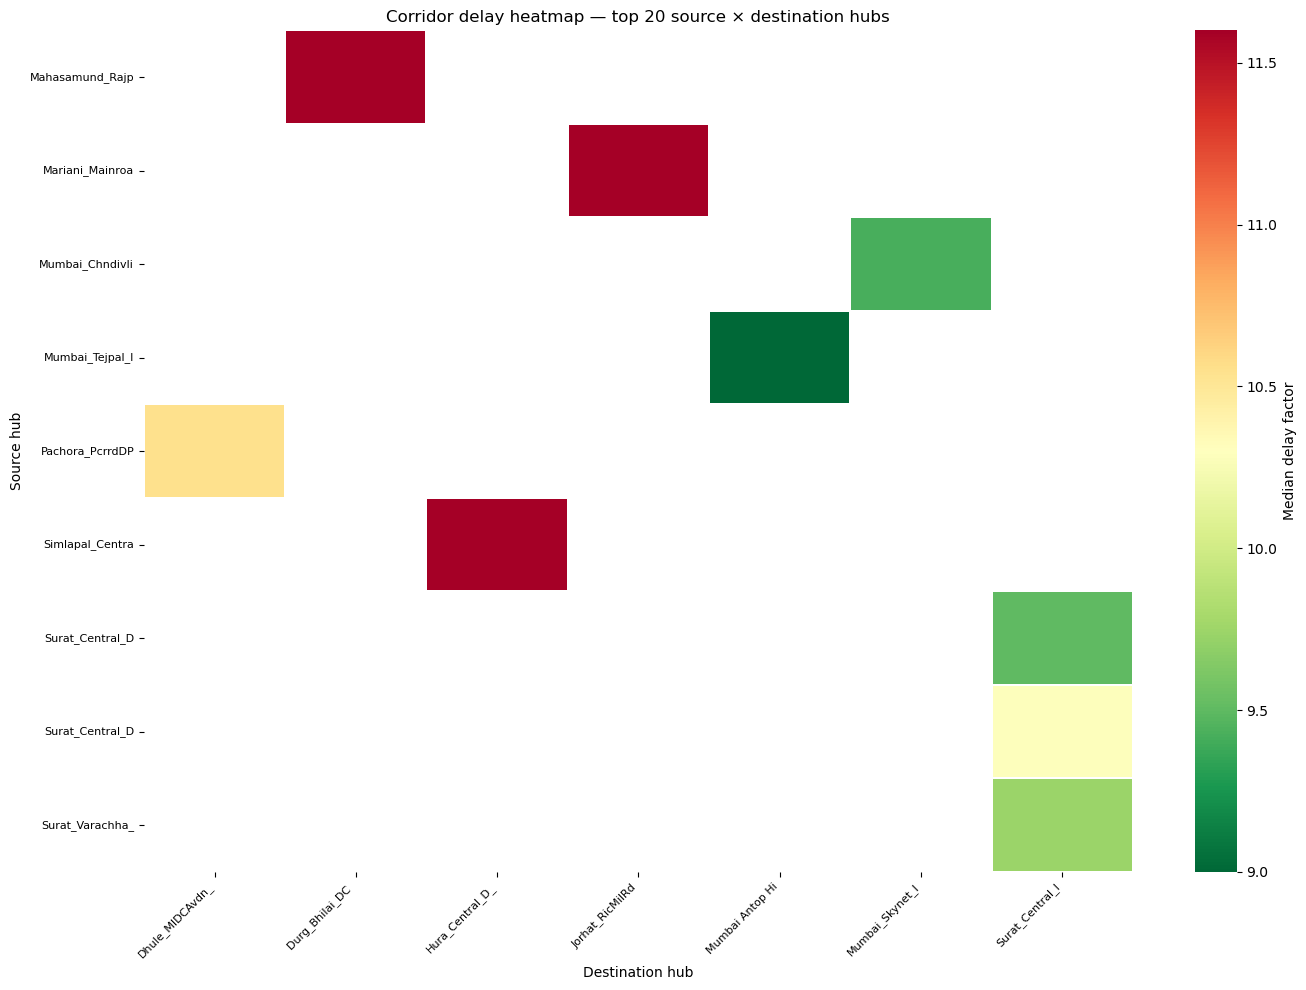

In [29]:
# Corridor delay heatmap
top_src = corridor_audit.groupby('source_name')['weight'].mean().nlargest(20).index
top_dst = corridor_audit.groupby('dest_name')['weight'].mean().nlargest(20).index

heat_df = (
    corridor_audit[
        corridor_audit['source_name'].isin(top_src) &
        corridor_audit['dest_name'].isin(top_dst)
    ].pivot_table(index='source_name', columns='dest_name',
                  values='weight', aggfunc='mean')
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heat_df, cmap='RdYlGn_r', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Median delay factor'},
            xticklabels=[x.split('(')[0][:15] for x in heat_df.columns],
            yticklabels=[y.split('(')[0][:15] for y in heat_df.index])
ax.set_title("Corridor delay heatmap — top 20 source × destination hubs")
ax.set_xlabel("Destination hub")
ax.set_ylabel("Source hub")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


In [44]:
bottleneck_path = f"{OUT_DIR}/bottleneck_hubs.parquet"
corridor_path   = f"{OUT_DIR}/corridor_audit.parquet"

combined.to_parquet(bottleneck_path, index=False)
corridor_audit.to_parquet(corridor_path, index=False)

print(f"{len(combined):,} hubs")
print(f"{len(corridor_audit):,} corridors")


1,657 hubs
2,783 corridors
